In [22]:
import jax
from astropy.table import Table
import numpy as np
import jax.numpy as jnp
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
from dustmaps.config import config
import dustmaps.edenhofer2023
import healpy as hp
import astropy as ap
from astropy.coordinates import SkyCoord
from dustmaps.edenhofer2023 import Edenhofer2023Query
import jax.random as jr
from astropy.io import fits
from Better_HMC import HMCSampler 
import jax.scipy.special as jss
import arviz as az
import blackjax
print(blackjax.__version__)

gc_builtin = SkyCoord(0*u.deg, 0*u.deg, frame='galactic').icrs
t = Table.read("gc_sightline.fits")   # add the path if the notebook runs elsewhere,
                                       # e.g. "Gaia XP/gc_sightline.fits"
star_coords = SkyCoord(np.asarray(t["ra"])*u.deg, np.asarray(t["dec"])*u.deg)
t["sep_gc_deg"] = star_coords.separation(gc_builtin).deg


plx_np = t["parallax"]              # parallax measurements (mas)
plx = jnp.asarray(np.asarray(plx_np).astype(np.float32))
plx_err_np = t["parallax_err"]         # their uncertainties (mas)
plx_err = jnp.asarray(np.asarray(plx_err_np).astype(np.float32))
ext_np  = t["ext"]                  # extinction
ext = jnp.asarray(np.asarray(ext_np).astype(np.float32))
ext_err_np = t["ext_err"]
ext_err = jnp.asarray(np.asarray(ext_err_np).astype(np.float32))
sep_np = t["sep_gc_deg"]
separation = jnp.asarray(np.asarray(sep_np).astype(np.float32))
print(t.info())

with fits.open("mean_and_std_healpix.fits") as hdul:
    hdul.info()
    print(hdul['MEAN'].header['ORDERING'])
    print(hdul['STD.'].header['ORDERING'])
    galactic_center_healpix = hp.pixelfunc.ang2pix(256, theta = 0.0, phi = 0.0, nest = True, lonlat = True)
    mean_along_center = jnp.asarray(hdul["MEAN"].data[:, galactic_center_healpix].astype(np.float32))
    std_along_center  = jnp.asarray(hdul["STD."].data[:, galactic_center_healpix].astype(np.float32))
    radial_centers    = jnp.asarray(hdul["RADIAL PIXEL CENTERS"].data.field(0),    dtype=jnp.float32)
    radial_boundaries = jnp.asarray(hdul["RADIAL PIXEL BOUNDARIES"].data.field(0), dtype=jnp.float32)
    distance_gaps = np.diff(radial_boundaries)

# 1000/x is its own inverse so this fcn is also plx_to_dist
def dist_to_plx(dist):
    return 1000/dist

def get_x_err_basic(plx_err, plx):
    return 1000*(plx**(-2))*plx_err

def logposterior_on_r(r, w, w_err):
    p_w_given_r = -0.5*(w - 1000/r)**2/(w_err**2) 
    p_r = distance_logprior(r)
    return p_r + p_w_given_r

def get_x_err_advanced(plx_err, plx):
    x = jnp.linspace(0.1, 100000, 20000)
    log_posterior = logposterior_on_r(x, plx, plx_err)
    y = jnp.exp(log_posterior - jnp.max(log_posterior))
    Z    = jnp.trapezoid(y, x)                    
    mean = jnp.trapezoid(x * y, x) / Z
    var  = jnp.trapezoid((x - mean) ** 2 * y, x) / Z
    return jnp.sqrt(var)

def distance_logprior(r):
    return jnp.where(r > 0, -r/10000, -jnp.inf)




assert mean_along_center.shape == distance_gaps.shape
num_stars = plx.size
distances_psc = dist_to_plx(plx)

linspace = jnp.linspace(0.1, 20000, 500)
x_err_basic = jax.vmap(get_x_err_basic, in_axes=(None, 0))(0.1, 1000/linspace)
x_err_advanced = jax.vmap(get_x_err_advanced, in_axes=(None, 0))(0.1, 1000/linspace)
plt.plot(linspace, x_err_basic, label = "Propogation of Uncertainty Error")
plt.plot(linspace, x_err_advanced, label = "Square Root of integrated posterior variance (x^2 included in exponential prior)")
plt.xscale("log")
plt.yscale("log")
plt.xlim(100, 100000)
plt.xlabel("Distance")
plt.ylabel("Distance error (given plx_err = 0.1)")
plt.legend()


1.6.2
<Table length=54602>
     name       dtype 
-------------- -------
gdr3_source_id   int64
            ra float32
           dec float32
      parallax float32
  parallax_err float32
           ext float32
       ext_err float32
        teff_K float32
           feh float32
          logg float32
  plx_over_err float32
    sep_gc_deg float64
None
Filename: mean_and_std_healpix.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       9   ()      
  1  MEAN          1 ImageHDU        19   (786432, 516)   float32   
  2  STD.          1 ImageHDU        19   (786432, 516)   float32   
  3  RADIAL PIXEL CENTERS    1 BinTableHDU     20   516R x 1C   [E]   
  4  RADIAL PIXEL BOUNDARIES    1 BinTableHDU     20   517R x 1C   [E]   
  5  MEAN OF INTEGRATED INNER 68.8 PC    1 ImageHDU        16   (786432,)   float32   
  6  STD. OF INTEGRATED INNER 68.8 PC    1 ImageHDU        16   (786432,)   float32   
NEST
NEST


KeyboardInterrupt: 

In [ ]:
num_dimensions = 600
num_fourier_dimensions = 900
left_distance_padding = 40
right_distance_padding = 600
min_distance = radial_boundaries[0] - left_distance_padding
max_distance = radial_boundaries[radial_boundaries.size - 1] + right_distance_padding
dx = (max_distance - min_distance)/(num_dimensions - 1)
# This is the analouge of fixed_points_linspace
dust_x_linspace = jnp.arange(num_dimensions)*dx + min_distance
fourier_length = dx*(num_fourier_dimensions - 1)
num_fitting_params = 3
omegas = 2*jnp.pi*jnp.fft.fftfreq(num_fourier_dimensions, d = dx)
error_bars_on_data = 0.025

cumulative_integrated_dust = jnp.concatenate(
    [jnp.array([0.0]), jnp.cumsum(mean_along_center * distance_gaps)])

Text(0.5, 1.0, 'Distrubtion of Distances for Gaia XP stars within 0.3 degree separation from the GC')

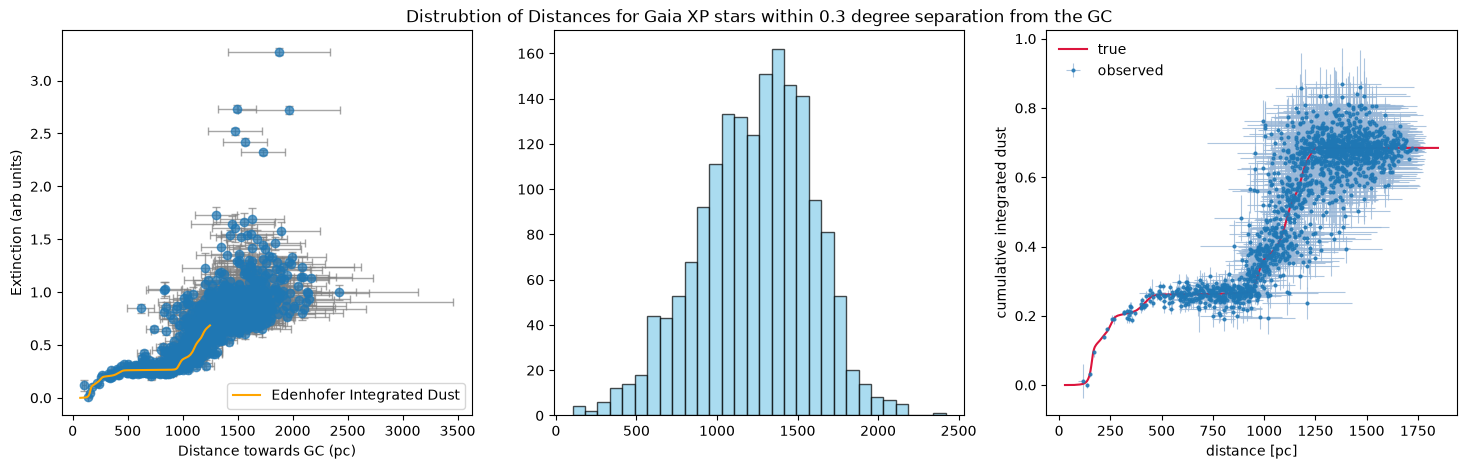

In [ ]:
rng = jr.PRNGKey(0)
rng, k1, k2 = jr.split(rng, 3)
# These are star locations
x_obs_true = distances_psc
y_obs_true = jnp.interp(x_obs_true, radial_boundaries, cumulative_integrated_dust)
y_obs_err = jr.normal(k1, shape = (num_stars,))*ext_err
y_obs = y_obs_true + y_obs_err




fake_plx_obs_true = dist_to_plx(x_obs_true)
# 1) Get what the parallax should be 2) Add error to get noisy parallax 3) Convert back the noisy parallax to distance
fake_plx_obs = fake_plx_obs_true + jr.normal(k2, shape = (num_stars, ))*plx_err
x_obs = dist_to_plx(fake_plx_obs)


mask = (separation < 0.3) & (fake_plx_obs - plx_err > 1000/1800) & (fake_plx_obs + plx_err < 1000/40)
x_obs = x_obs[mask]
y_obs = y_obs[mask]
fake_plx_obs = fake_plx_obs[mask]
x_error = jax.vmap(get_x_err_basic)(plx_err[mask], fake_plx_obs)
# gets rid of crazy error bars on x
x_error = x_error.at[x_error > 500].set(500)
num_data = x_obs.size
inv_cov_data_matrix = jnp.linalg.inv(jnp.diag(ext_err[mask]**2))
inv_cov_plx_matrix = jnp.linalg.inv(jnp.diag(plx_err[mask]**2))



fig, axes = plt.subplots(1, 3, figsize = (18, 5))
axes[2].errorbar(x_obs, y_obs, yerr = ext_err[mask], xerr = x_error, fmt='.', markersize=4, ecolor='#9ab8d8', elinewidth=0.8, capsize=0, alpha=0.8, label='observed')
axes[2].plot(dust_x_linspace, jnp.interp(dust_x_linspace, radial_boundaries, cumulative_integrated_dust), color='crimson', lw=1.5, label='true')
axes[2].set_xlabel('distance [pc]')
axes[2].set_ylabel('cumulative integrated dust')
axes[2].legend(frameon=False)
dist_err = jax.vmap(get_x_err_basic)(plx_err, plx)
distances_psc = 1000/plx
axes[0].errorbar(distances_psc[mask], ext[mask],
             yerr=ext_err[mask],      # vertical error bars
             xerr=dist_err[mask],     # horizontal error bars (optional)
             fmt='o',                 # marker style, no connecting line
             ecolor='gray',           # error bar color
             elinewidth=1,
             capsize=3,               # little caps on the ends
             alpha=0.7)
axes[0].plot(radial_boundaries, cumulative_integrated_dust, color="orange", alpha=1, zorder=5, label="Edenhofer Integrated Dust")
axes[0].legend()
axes[0].set_xlabel("Distance towards GC (pc)")
axes[0].set_ylabel("Extinction (arb units)")

axes[1].hist(
    distances_psc[mask], bins=30, color="skyblue", edgecolor="black", alpha=0.7
)
axes[1].set_title("Distrubtion of Distances for Gaia XP stars within 0.3 degree separation from the GC")



In [ ]:
def mask_cov_square(cov, indices_to_keep):
    n = cov.shape[0]
    idx  = np.arange(n)
    M = np.eye(n)                              # identity baseline
    M[np.ix_(indices_to_keep, indices_to_keep)] = cov[np.ix_(indices_to_keep, indices_to_keep)]
    return M

def mask_cov_diagonal(cov, indices_to_keep):
    cov_diag = jnp.diagonal(cov)
    n = cov_diag.size
    M_diag = np.ones(n)
    M_diag[indices_to_keep] = cov_diag[indices_to_keep]
    return jnp.diag(M_diag)

num_overall_steps = 500
burn_in = 50
num_integration_steps = 3500
initial_step_size = 0.0004
step_size = initial_step_size
#inv_mass_matrix = jnp.eye(num_fourier_dimensions + num_fitting_params + num_data)

num_initial_dims = num_fourier_dimensions + num_fitting_params
indices_to_keep = np.concatenate([np.arange(0, 20), np.arange(num_initial_dims-20, num_initial_dims)])
# This mass matrix may be OK but I don't know what it was generated on so it is garbage!!! do not use
inv_mass_matrix = mask_cov_diagonal(jnp.diag(jnp.asarray(np.load('inv_mass_matrix_Gaia_XP_real_error_bars_synthetic_data.npy'))), indices_to_keep)

ending_diag_values = x_error**2
ending_indices = jnp.arange(num_fourier_dimensions + num_fitting_params, num_fourier_dimensions + num_fitting_params + num_data)
inv_mass_matrix = inv_mass_matrix.at[ending_indices, ending_indices].set(ending_diag_values)


initial_logvar = 4.0
initial_lognu = 0
initial_offset = -7.6

logvar_prior_mean = initial_logvar
lognu_prior_mean = 0.0
offset_prior_mean = initial_offset

fixed_logscale = jnp.log(2*fourier_length)

normalization_factor = num_fourier_dimensions/jnp.sqrt(fourier_length)

doing_burn_in = False
use_NUTS = False
use_blackjax_hmc = False
window_adapt_square_mass_matrix = False


In [ ]:
def hartley(x):
    fft = jnp.fft.fft(x)
    return jnp.real(fft) - jnp.imag(fft)

def cumulative_trapezoid(y, dx):
    seg = dx * (y[:-1] + y[1:]) / 2.0            # area of each trapezoid segment
    return jnp.concatenate([jnp.zeros(1, y.dtype), jnp.cumsum(seg)])


def exponentiated_integrated_density(logdensity):
    density = jnp.exp(logdensity)
    return cumulative_trapezoid(density, dx)

def response_function(xi, r, inference_params, offset):
    field = fft_field_hartley(xi, inference_params) + offset
    exp_int_field = exponentiated_integrated_density(field)
    return jnp.interp(r, dust_x_linspace, exp_int_field)

def general_matern_spectral_density(omega, inference_params, jitter = 1e-6):
        logvar, lognu = inference_params
        #logvar, lognu = 5.0, jnp.log(0.475)
        logscale = fixed_logscale
        nu = jnp.exp(lognu)
        log_ratio = jss.gammaln(nu + 0.5) - jss.gammaln(nu)
        r = jnp.square(omega) * jnp.exp(2 * logscale - jnp.log(2.0) - lognu)
        logdensity = logvar + log_ratio - 0.5*jnp.log(2*nu) + logscale - (nu + 0.5)*jnp.log1p(r)
        result = 2*jnp.sqrt(jnp.pi)*jnp.exp(logdensity)
        return jnp.where(omega > 0, result, result * (1.0 + jitter))

def matern_magnitude(omegas, inference_params):
     return jnp.sqrt(general_matern_spectral_density(omegas, inference_params))


def fft_field_hartley(noise, inference_params):
    size = noise.shape[0]
    raw_average_amplitude_data = matern_magnitude(omegas, inference_params)
    H = noise * raw_average_amplitude_data          # elementwise, whole array, in order
    y_data = (hartley(H) / size) * normalization_factor 
    return y_data[0:num_dimensions]



def logvarprior(logvar):
    return -0.5*(logvar - logvar_prior_mean)**2
def lognuprior(lognu):
    return -0.5*(lognu - lognu_prior_mean)**2
def logoffsetprior(offset):
    return -0.5*(offset - offset_prior_mean)**2


def negative_logdensity(x):
    logvar = x[0]
    lognu = x[1]
    offset = x[2]
    xi = x[3:3 + num_fourier_dimensions]
    r = x[3 + num_fourier_dimensions:]
    # hardcoded r back to fixed values
    #r = x_obs_true
    inference_params = (logvar, lognu)
    # There are priors on everything: logvar, lognu, offset, xi, and r
    negative_log_p_s = -logvarprior(logvar) - lognuprior(lognu) - logoffsetprior(offset) + 0.5*xi.T @ xi - jnp.sum(distance_logprior(r))
    field_res = y_obs - response_function(xi, r, inference_params, offset)
    plx_res = fake_plx_obs - dist_to_plx(r)
    # P(all data given field, params, distance) is now the probability of observing the extinctions (first term) times the probabilty of observing the correct distances (second term)
    negative_log_p_d_given_s = 0.5*field_res.T @ inv_cov_data_matrix @ field_res + 0.5*plx_res.T @ inv_cov_plx_matrix @ plx_res
    return negative_log_p_s + negative_log_p_d_given_s


if(doing_burn_in):
    initial_coordinates = jnp.zeros(num_fourier_dimensions + num_fitting_params) 
    initial_coordinates = initial_coordinates.at[0].set(initial_logvar)
    initial_coordinates = initial_coordinates.at[1].set(initial_lognu)
    initial_coordinates = initial_coordinates.at[2].set(initial_offset)
    initial_coordinates = jnp.concatenate([initial_coordinates, x_obs])
else:
    initial_coordinates = jnp.asarray(np.load("last_position_Gaia_XP_real_error_bars_synthetic_data.npy"))

# Size of initial coordinates: num_fourier_dimensions + num_fitting_params + num_data
num_good_samples = num_overall_steps - burn_in
time_arr = jnp.arange(num_good_samples)



In [ ]:
rng = jr.PRNGKey(5)
logdensity_fn = lambda x: -negative_logdensity(x)

print(initial_coordinates.shape)
if(use_NUTS):
        def inference_loop(rng_key, kernel, initial_state, num_samples):
            @jax.jit
            def one_step(state, key):
                state, info = kernel(key, state)
                return state, (state, info)
            keys = jr.split(rng_key, num_samples)
            _, (states, infos) = jax.lax.scan(one_step, initial_state, keys)
            return states, infos


        warmup = blackjax.window_adaptation(blackjax.nuts, logdensity_fn, is_mass_matrix_diagonal= not window_adapt_square_mass_matrix, initial_inverse_mass_matrix=jnp.diagonal(inv_mass_matrix),   imm_shrinkage_to_previous=0.0)
        (state, parameters), _ = warmup.run(k1, initial_coordinates, num_steps=burn_in)
        nuts = blackjax.nuts(logdensity_fn, **parameters)
        initial_state = state

        states, infos = inference_loop(k2, nuts.step, initial_state, num_good_samples)

        overall_data_arr = states.position
        accept_prob_arr  = infos.acceptance_rate
elif use_blackjax_hmc:
    def inference_loop(rng_key, kernel, initial_state, num_samples):
        @jax.jit
        def one_step(state, key):
            state, info = kernel(key, state)
            return state, (state, info)
        keys = jr.split(rng_key, num_samples)
        _, (states, infos) = jax.lax.scan(one_step, initial_state, keys)
        return states, infos

    # HMC needs num_integration_steps; pass it through window_adaptation.
    warmup = blackjax.window_adaptation(
        blackjax.hmc, logdensity_fn,
        num_integration_steps=num_integration_steps,
        is_mass_matrix_diagonal=not window_adapt_square_mass_matrix,
    )
    (state, parameters), _ = warmup.run(k1, initial_coordinates, num_steps=burn_in)

    # ...and again when building the tuned kernel.
    hmc = blackjax.hmc(logdensity_fn, **parameters)
    initial_state = state

    states, infos = inference_loop(k2, hmc.step, initial_state, num_good_samples)

    overall_data_arr = states.position
    accept_prob_arr  = infos.acceptance_rate
    np.save('blackjax_cov_matrix.npy', np.asarray(parameters["inverse_mass_matrix"]))
else :
    sampler = HMCSampler(
        negative_logdensity= negative_logdensity,
        num_integration_steps =  num_integration_steps,
        step_size= step_size,
        inv_mass_matrix = inv_mass_matrix,
        #inv_mass_matrix = jnp.diag(jnp.array(np.load('blackjax_cov_matrix.npy'))),
        alpha=1.0
    )

    overall_data_arr, overall_momentum_arr, accept_prob_arr = sampler.sample(
        start_position=initial_coordinates, 
        num_samples=num_overall_steps,
        burn_in = burn_in,
        rng_key=rng
    )



np.save('overall_data_Gaia_XP_real_error_bars_synthetic_data.npy', overall_data_arr)
np.save('accept_prob_Gaia_XP_real_error_bars_synthetic_data.npy', accept_prob_arr)



logvars = overall_data_arr[:, 0]
lognus = overall_data_arr[:, 1]
offsets = overall_data_arr[:, 2]
overall_extinction_arr = overall_data_arr[:, 3:3 + num_fourier_dimensions]  
overall_star_location_arr = overall_data_arr[:, 3 + num_fourier_dimensions:]









mean_star_location_arr = overall_star_location_arr.mean(axis=0)
logscales = jnp.zeros_like(logvars)
inference_params = (logvars, lognus)

overall_extinction_arr_raw = jax.vmap(fft_field_hartley, in_axes=(0, 0))(
    overall_extinction_arr, inference_params
) 
overall_extinction_arr_raw = overall_extinction_arr_raw + offsets[:, None]
overall_extinction_arr_exp = jax.vmap(exponentiated_integrated_density, in_axes=(0))(
    overall_extinction_arr_raw
)
overall_extinction_arr_raw = overall_extinction_arr_raw[:, 0:num_dimensions]
overall_extinction_arr_exp = overall_extinction_arr_exp[:, 0:num_dimensions]

mean_extinction_raw = overall_extinction_arr_raw.sum(axis=0)/num_good_samples
mean_position_exp = overall_extinction_arr_exp.sum(axis=0)/num_good_samples
vars = jnp.exp(logvars)
scales = jnp.exp(logscales)
nus = jnp.exp(lognus)
cov= jnp.cov(overall_data_arr, rowvar = False)



(2643,)


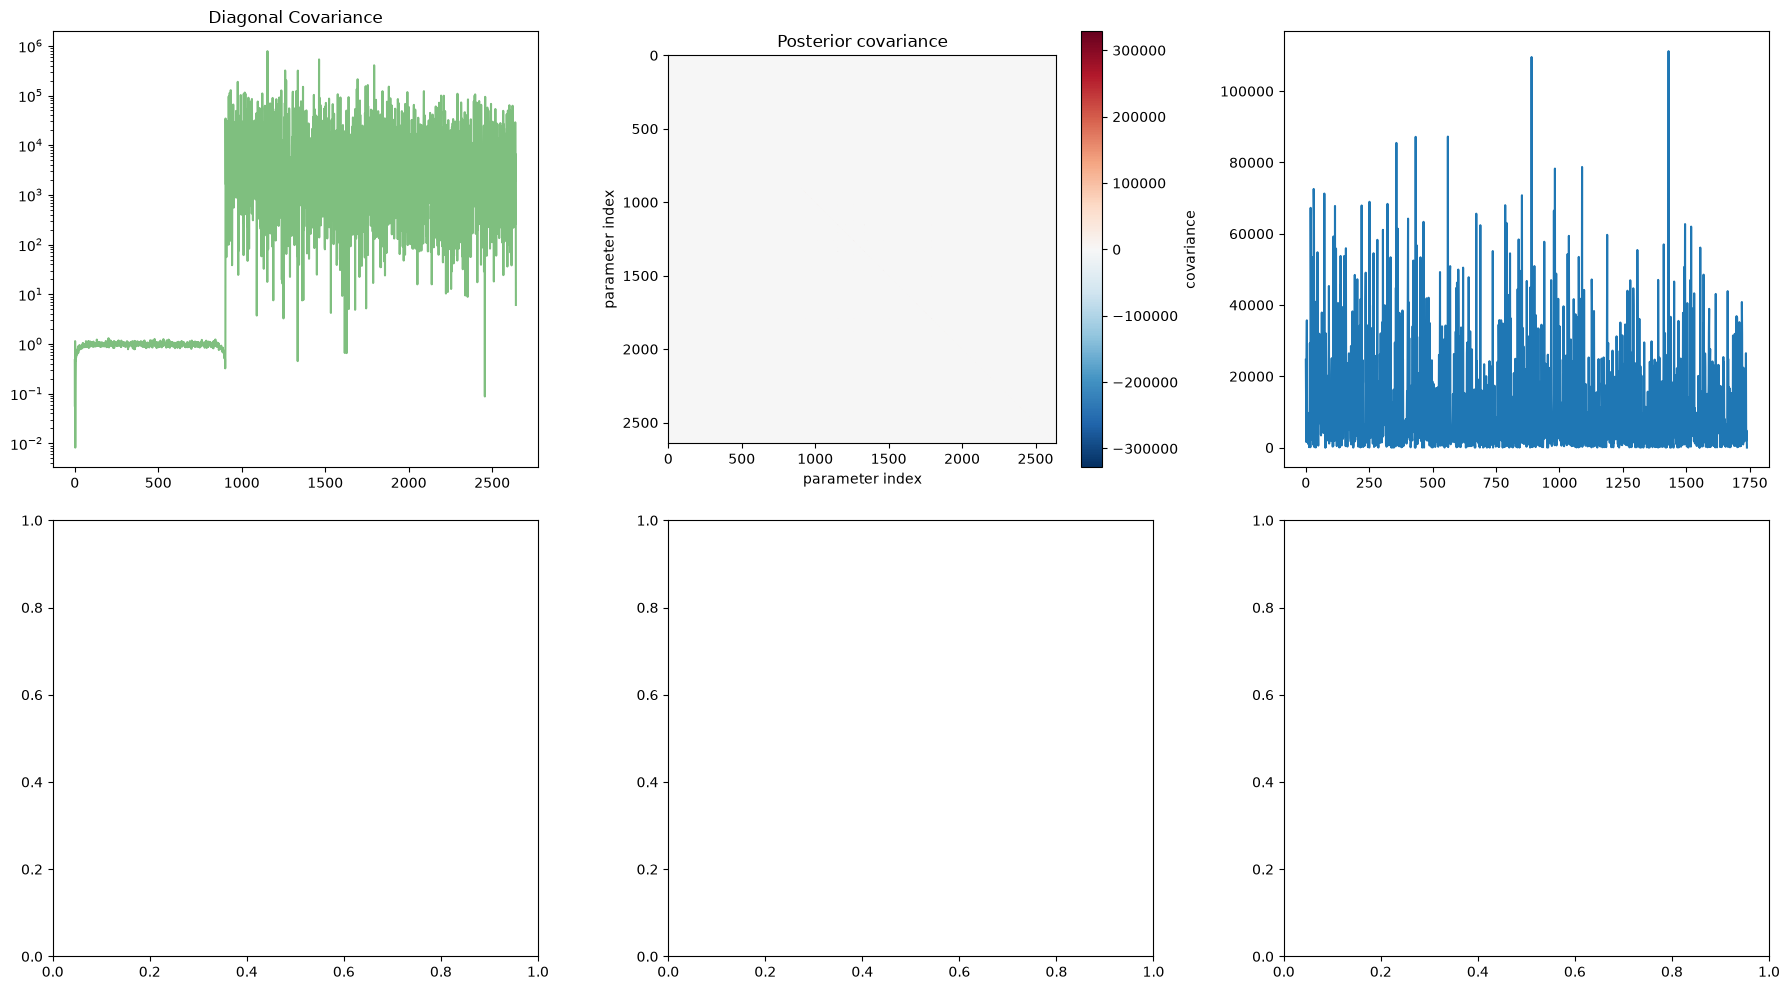

In [ ]:
fig, axes = plt.subplots(2, 3, figsize = (18, 10))
timegrid = jnp.arange(num_fourier_dimensions + num_fitting_params + num_data)
axes[0][0].plot(timegrid, jnp.diagonal(cov), color = "Green", alpha = 0.5)
axes[0][0].set_title("Diagonal Covariance")
axes[0][0].set_yscale("log")
axes[0][2].plot(jnp.arange(plx_err[mask].size), ending_diag_values)
C = np.asarray(cov)
off = C - np.diag(np.diag(C))
vmax = np.abs(off).max()         # symmetric limits so white = 0
im = axes[0][1].imshow(C, cmap='RdBu_r', vmin= -vmax, vmax=vmax)
fig.colorbar(im, ax=axes[0][1], label='covariance')
axes[0][1].set_title('Posterior covariance')
axes[0][1].set_xlabel('parameter index')
axes[0][1].set_ylabel('parameter index')


if use_NUTS or use_blackjax_hmc:
    step_size = parameters['step_size']
    inv_mass_matrix = parameters['inverse_mass_matrix']   # not 'inv_mass_matrix'
    if(window_adapt_square_mass_matrix):
        C = np.asarray(inv_mass_matrix)
        off = C - np.diag(np.diag(C))
        vmax = np.abs(off).max()        
        im = axes[1][0].imshow(jnp.log(C), cmap='RdBu_r', vmin= -vmax, vmax=vmax)
        axes[1][0].colorbar(im, ax=axes[0], label='covariance')
        axes[1][0].set_title('Posterior covariance')
        axes[1][0].set_xlabel('parameter index')
        axes[1][0].set_ylabel('parameter index')
        axes[1][1].plot(jnp.arange(jnp.diagonal(inv_mass_matrix)).size, inv_mass_matrix)
    else :
        axes[1][0].plot(jnp.arange(inv_mass_matrix.size), inv_mass_matrix)

plt.tight_layout()
plt.show()

np.save('cov_matrix_Gaia_XP_real_error_bars_synthetic_data.npy', cov)




450
450
ESS for Variance parameter (index 0): 74.76668279031179
ESS for Nu parameter (index 1): 72.83142685472095
ESS for 29th parameter (index 31): 221.2570012856725
Use NUTS? False Use blackjax HMC? False Initial Step Size: 0.0004 Step Size: 0.0004 Num integration steps (only valid if no NUTS) 3500 Burn in: 50
Average acceptance probability (acceptance rate) is: 0.8761682510375977
Num dimensions: 600 Num data: 1740 Total length: 1819.4813232421875 Noise on each point: 0.025 Num HMC trials: 500
(450, 600)
Error bars on data: 0.025
Logvar prior mean: 4.0 Lognu prior mean: 0.0 Offset prior mean -7.6 Initial logvar/lognu/offset values: 4.0, 0, -7.6
Average chi_2 statistic based on the prior: 0.9655583500862122
Average chi_2 statistic based on the extinction per star: 0.9647613763809204
Average chi_2 statistic based on the distance/parallax per star: 1.061638593673706


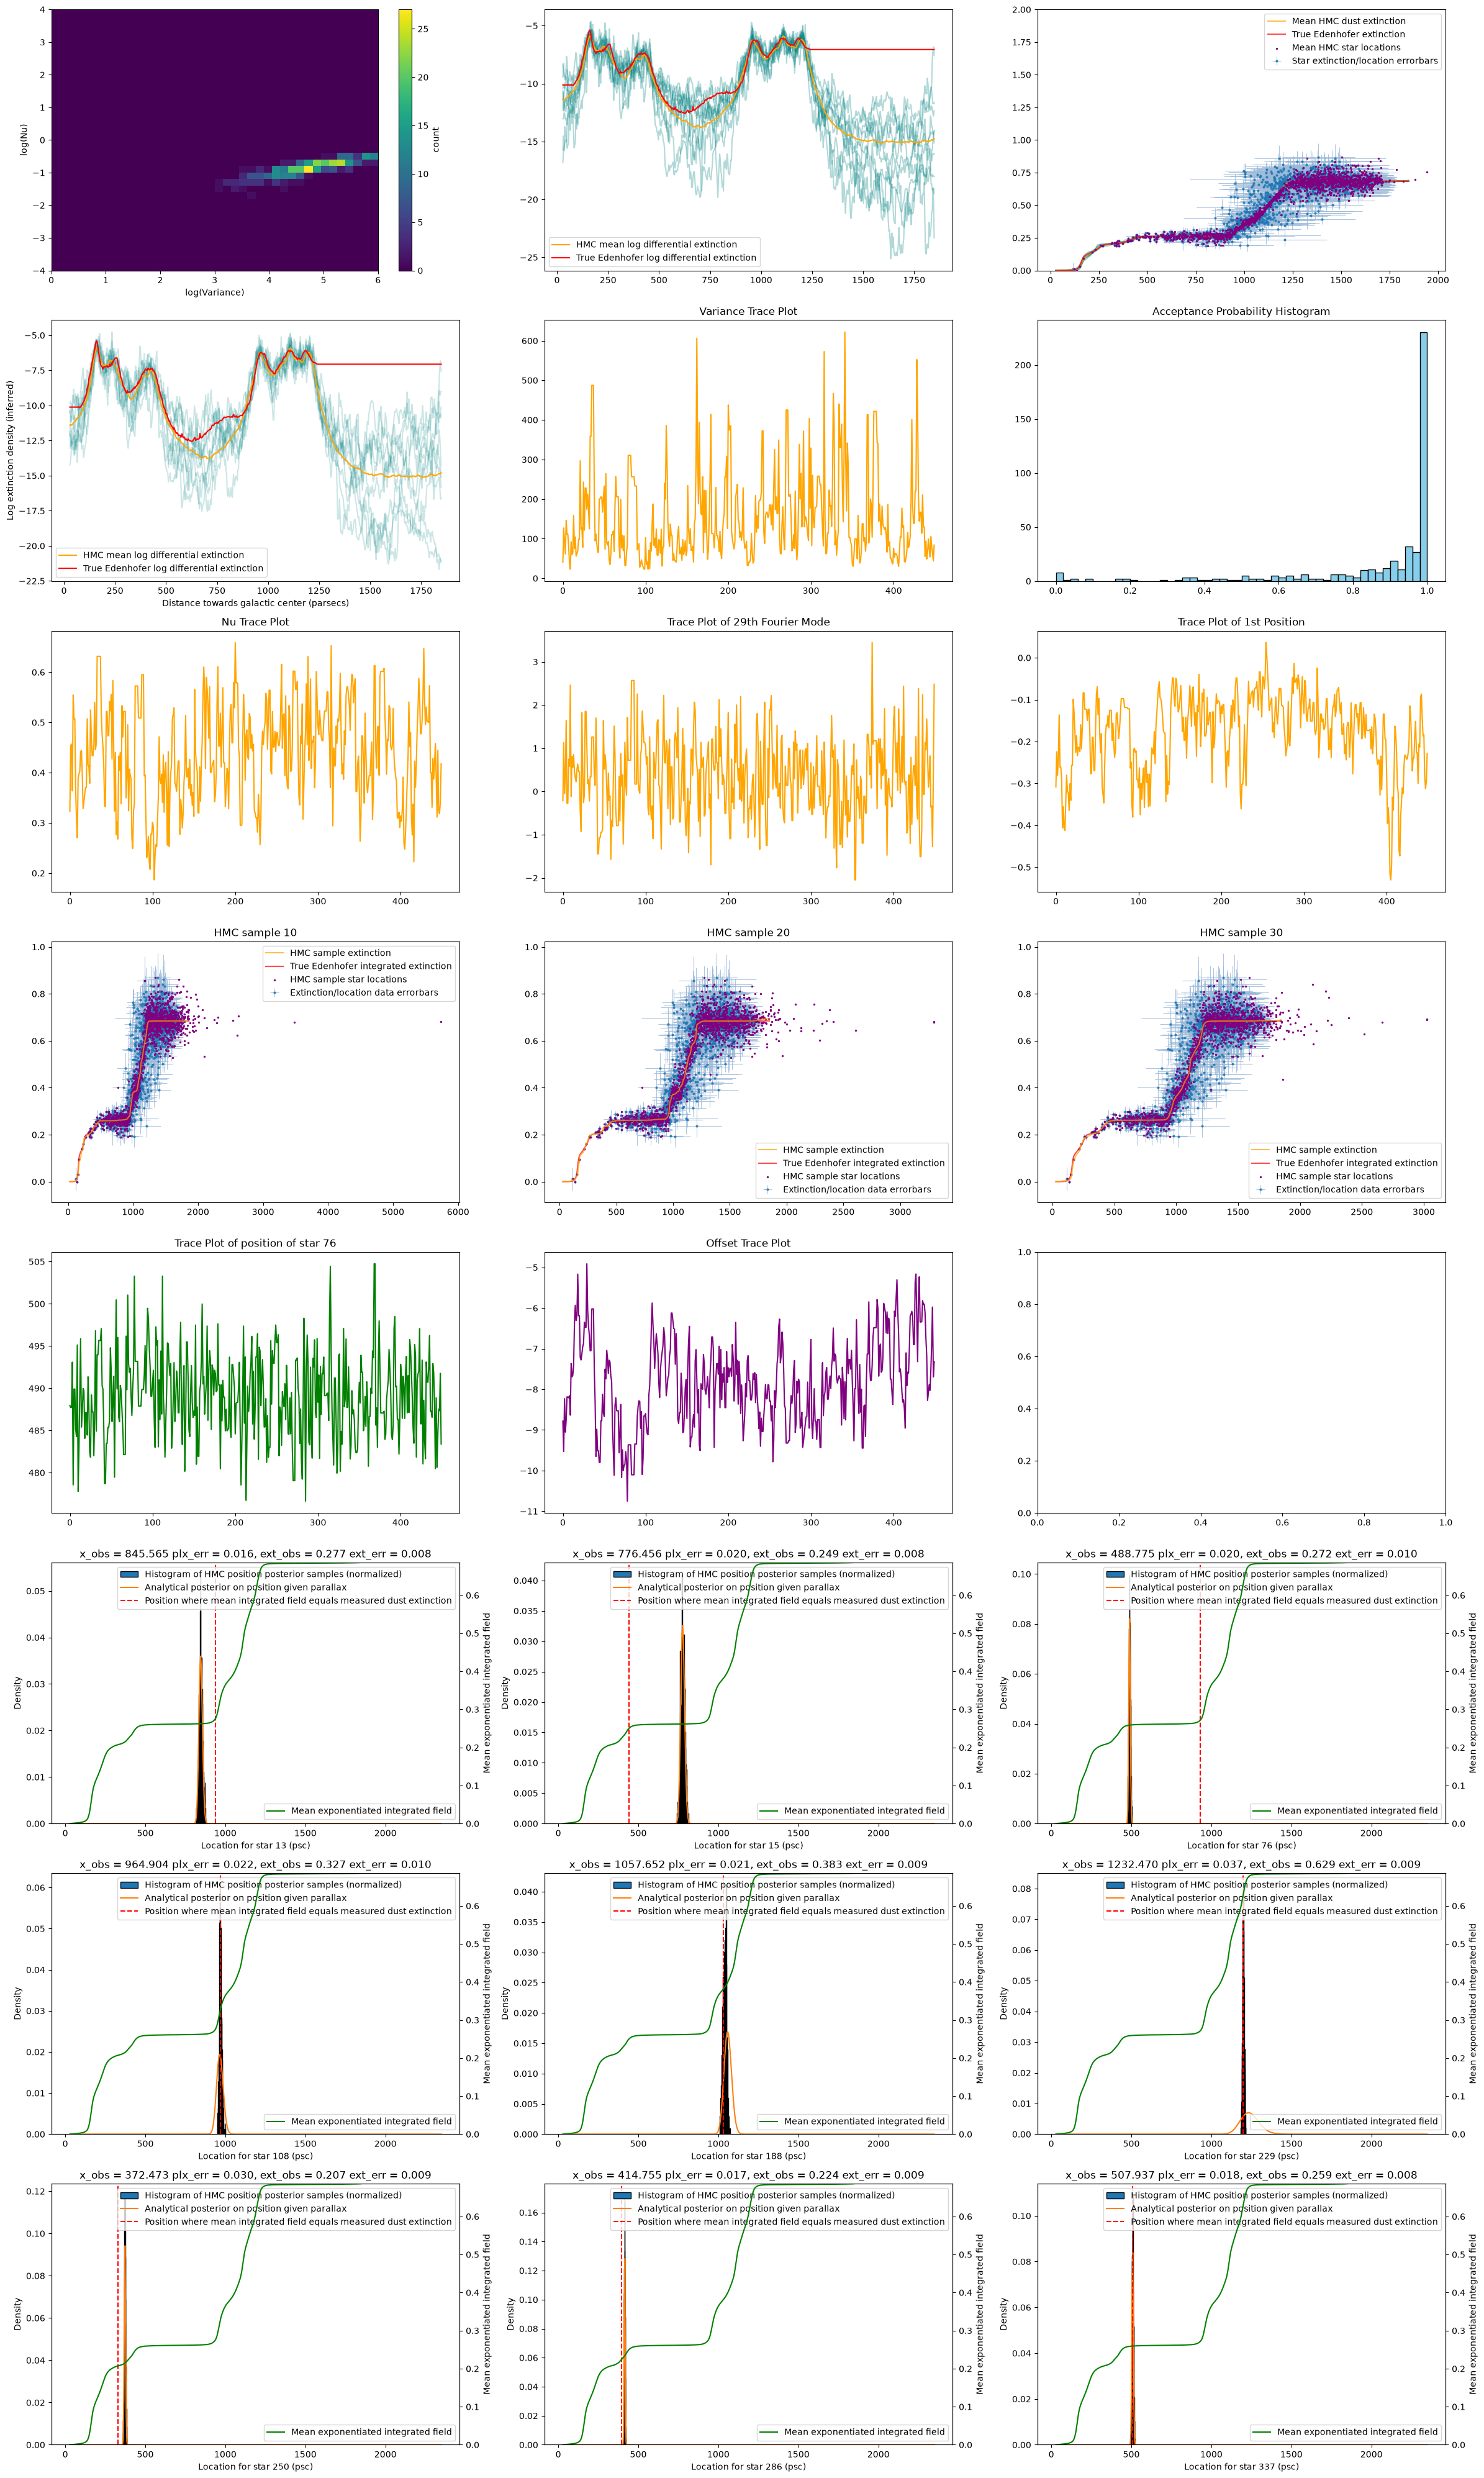

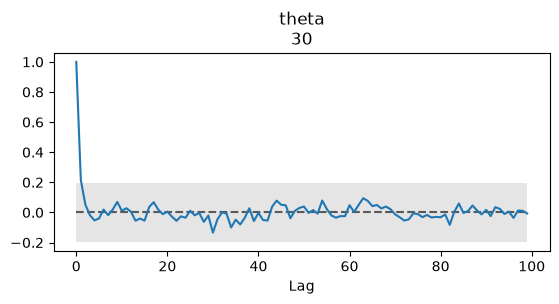

In [ ]:

fig, axes = plt.subplots(8, 3, figsize = (24, 40))
star_indices = jnp.arange(num_data)
star_mask = (mean_star_location_arr < 1200) & (ext_err[mask] < 0.01)
star_indices = star_indices[star_mask]
samples_to_highlight = [10, 20, 30]
for i in range (0, 10):
    axes[0][2].plot(dust_x_linspace, overall_extinction_arr_exp[50*i, :], color = "teal", alpha = 0.3)
    axes[0][1].plot(dust_x_linspace, overall_extinction_arr_raw[50*i, :], color = "teal", alpha = 0.3)



print(vars.size)
print(time_arr.size)

# rows you're actually plotting
indices = np.array([30*i for i in range(10)])
mask_indices = np.where(lognus > 0)[0]         
#indices = np.concatenate([indices, mask_indices])

values = np.asarray(jax.vmap(negative_logdensity)(overall_data_arr[indices, :]))   # shape (n_lines,)

# colormap + normalization over the full value range
cmap = plt.cm.viridis
norm = plt.Normalize(vmin=values.min(), vmax=values.max())

for k, i in enumerate(range(indices.size)):
    axes[1][0].plot(
        dust_x_linspace,
        overall_extinction_arr_raw[indices[i], :],
        color = "teal",
        #color=cmap(norm(values[k])),
        alpha=0.2,
    )

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
#cbar = fig.colorbar(sm, ax=axes[1][0])
#cbar.set_label("Negative logdensity")   

axes[1][0].set_ylabel("Log extinction density (inferred)")
axes[1][0].set_xlabel("Distance towards galactic center (parsecs)")


axes[0][1].plot(dust_x_linspace, mean_extinction_raw, color = "orange", alpha = 1, label = "HMC mean log differential extinction")
axes[1][0].plot(dust_x_linspace, mean_extinction_raw, color = "orange", alpha = 1, label = "HMC mean log differential extinction")
axes[0][1].plot(dust_x_linspace, jnp.interp(dust_x_linspace, radial_centers, jnp.log(mean_along_center)), color = "red", alpha = 1, label = "True Edenhofer log differential extinction")
axes[1][0].plot(dust_x_linspace, jnp.interp(dust_x_linspace, radial_centers, jnp.log(mean_along_center)), color = "red", alpha = 1, label = "True Edenhofer log differential extinction")
axes[0][2].plot(dust_x_linspace, mean_position_exp, color = "orange", alpha = 0.7, zorder = 5, label = "Mean HMC dust extinction")
axes[0][2].plot(dust_x_linspace, jnp.interp(dust_x_linspace, radial_boundaries, cumulative_integrated_dust), color = "red", alpha = 0.7, zorder = 7, label = "True Edenhofer extinction")
axes[0][2].set_ylim(0, 2)
axes[0][2].errorbar(x_obs, y_obs, yerr = ext_err[mask], xerr = x_error, fmt='.', markersize=4, ecolor='#9ab8d8', elinewidth=0.8, capsize=0, alpha=0.8, label="Star extinction/location errorbars")
axes[0][2].scatter(mean_star_location_arr, y_obs, color = "purple", s = 2, zorder = 10, label = "Mean HMC star locations")

axes[1][0].legend()

number_bins_x = 40
number_bins_y = 40
x_min, x_max = -0, 6
y_min, y_max = -4, 4
dx = (x_max - x_min)/number_bins_x
dy = (y_max - y_min)/number_bins_y

x_centers = (jnp.arange(number_bins_x) + 0.5)*dx + x_min
y_centers = (jnp.arange(number_bins_y) + 0.5)*dy + y_min
x_edges = jnp.arange(number_bins_x + 1)*dx + x_min
y_edges = jnp.arange(number_bins_y + 1)*dy + y_min

H_HMC_samples, _, _ = jnp.histogram2d(logvars, lognus, bins=[x_edges, y_edges])

im2 = axes[0][0].imshow(
    H_HMC_samples.T,
    origin='lower',
    extent=[x_min, x_max, y_min, y_max],
    aspect='auto',
    cmap='viridis',
)
fig.colorbar(im2, ax=axes[0][0], label='count')

axes[0][0].set_xlabel("log(Variance)")
axes[0][0].set_ylabel("log(Nu)")
axes[1][1].plot(time_arr, vars, color = "Orange")
axes[1][1].set_title("Variance Trace Plot")
axes[2][0].plot(time_arr, nus, color = "Orange")
axes[2][0].set_title("Nu Trace Plot")
axes[2][1].plot(time_arr, overall_extinction_arr[:, 28], color = "Orange")
axes[2][1].set_title("Trace Plot of 29th Fourier Mode")
axes[2][2].plot(time_arr, overall_extinction_arr[:, 0], color = "Orange")
axes[2][2].set_title("Trace Plot of 1st Position")
axes[1][2].set_title("Acceptance Probability Histogram")
axes[1][2].hist(accept_prob_arr, bins=50, edgecolor='black', color='skyblue')

axes[0][1].legend()
axes[0][2].legend()



for i in range (0, 3):
    axes[3][i].plot(dust_x_linspace, overall_extinction_arr_exp[samples_to_highlight[i], :], color = 'orange', alpha = 0.7, zorder = 4, label = "HMC sample extinction")
    axes[3][i].plot(dust_x_linspace, jnp.interp(dust_x_linspace, radial_boundaries, cumulative_integrated_dust), color = "red", alpha = 0.7, zorder = 2, label = "True Edenhofer integrated extinction")
    axes[3][i].errorbar(x_obs, y_obs, yerr = ext_err[mask], xerr = x_error, fmt='.', markersize=4, ecolor='#9ab8d8', elinewidth=0.8, capsize=0, alpha=0.8, zorder = 1, label = "Extinction/location data errorbars")
    axes[3][i].scatter(overall_star_location_arr[samples_to_highlight[i], :], y_obs, color = "purple", s = 2, zorder = 3, label = "HMC sample star locations")
    axes[3][i].set_title(f"HMC sample {samples_to_highlight[i]}")
    axes[3][i].legend()
    max_v = float(jnp.max(mean_position_exp))
    for j in range (0, 3):
        ax = axes[5 + j][i]
        ax.hist(overall_star_location_arr[:, star_indices[i + 3*j]], bins=30, edgecolor="black", density=True, label="Histogram of HMC position posterior samples (normalized)")
        ax.set_xlabel(f"Location for star {star_indices[i + 3*j]} (psc)")
        ax.set_ylabel("Density")
        star_linspace = jnp.linspace(min_distance, max_distance + 500, num_dimensions)
        log_r_posterior = logposterior_on_r(star_linspace, fake_plx_obs[star_indices[i + 3*j]], plx_err[mask][star_indices[i + 3*j]])
        r_posterior = jnp.exp(log_r_posterior - jnp.max(log_r_posterior))
        r_posterior = (r_posterior/jnp.sum(r_posterior))*num_dimensions/(max_distance + 500 - min_distance)
        ax.plot(star_linspace, r_posterior, label="Analytical posterior on position given parallax")
        ax.axvline(x=jnp.interp(y_obs[star_indices[i + 3*j]], mean_position_exp, dust_x_linspace),
                   color="red", linestyle="--",
                   label="Position where mean integrated field equals measured dust extinction")
        ax.set_title(f"x_obs = {x_obs[star_indices[i + 3*j]]:.3f} plx_err = {plx_err[mask][star_indices[i + 3*j]]:.3f}, ext_obs = {y_obs[star_indices[i + 3*j]]:.3f} ext_err = {ext_err[mask][star_indices[i + 3*j]]:.3f}")

        # --- right axis: green field curve, FIXED 0..max_v in every subplot ---
        ax2 = ax.twinx()
        ax2.plot(dust_x_linspace, mean_position_exp, color="green",
                 label="Mean exponentiated integrated field")
        ax2.set_ylim(0, max_v)                          # identical across all nine plots
        ax2.set_ylabel("Mean exponentiated integrated field")
        ax.legend()
        ax2.legend(loc = "lower right")
axes[4][0].plot(time_arr, overall_star_location_arr[:, star_indices[i]], color = "Green")
axes[4][0].set_title(f"Trace Plot of position of star {star_indices[i]}")
axes[4][1].plot(time_arr, offsets, color = "Purple")
axes[4][1].set_title("Offset Trace Plot")

fig.tight_layout()


posterior_samples = overall_data_arr[np.newaxis, :, :]  # add chain axis -> (1, num_samples, 50)

idata = az.from_dict({"posterior": {"theta": posterior_samples}})

param_index = 30  # first parameter (0-indexed)

az.plot_autocorr(idata, var_names="theta", coords={"theta_dim_0": [param_index]})

ess_all = az.ess(idata, var_names="theta")  # a Dataset, ESS for all 50 parameters at once

# Indices of interest: "first", "second", and "32nd" parameter, 0-indexed as 0, 1, 31
indices_of_interest = {
    "Variance": 0,
    "Nu": 1,
    "29th": 31,
}

for label, idx in indices_of_interest.items():
    ess_val = ess_all["theta"].sel(theta_dim_0=idx).values
    print(f"ESS for {label} parameter (index {idx}): {ess_val}")

print(f"Use NUTS? {use_NUTS} Use blackjax HMC? {use_blackjax_hmc} Initial Step Size: {initial_step_size} Step Size: {step_size} Num integration steps (only valid if no NUTS) {num_integration_steps} Burn in: {burn_in}")
print(f"Average acceptance probability (acceptance rate) is: {jnp.average(accept_prob_arr)}")
print(f"Num dimensions: {num_dimensions} Num data: {num_data} Total length: {max_distance - min_distance} Noise on each point: {error_bars_on_data} Num HMC trials: {num_overall_steps}")

print(overall_extinction_arr_raw.shape)

def average_chi_2_based_on_extinction(r, extinction, x_field, y_field, inverse_data_cov):
    def single(r_i, y_field_i):
        model_at_stars = jnp.interp(r_i, x_field, y_field_i)
        residual = extinction - model_at_stars
        return residual.T @ inverse_data_cov @ residual
    return jnp.average(jax.vmap(single, in_axes=(0, 0))(r, y_field))/extinction.size


def average_chi_2_based_on_r(r, plx_obs, inv_plx_cov):
    def single(r_i):
        residual = dist_to_plx(r_i) - plx_obs
        return residual.T @ inv_plx_cov @ residual
    return jnp.average(jax.vmap(single, in_axes = (0,))(r))/plx_obs.size


prior_variances = jnp.diag(cov)[3:3 + num_fourier_dimensions]
print(f"Error bars on data: {error_bars_on_data}")
print(f"Logvar prior mean: {logvar_prior_mean} Lognu prior mean: {lognu_prior_mean} Offset prior mean {offset_prior_mean} Initial logvar/lognu/offset values: {initial_logvar}, {initial_lognu}, {initial_offset}")
print(f"Average chi_2 statistic based on the prior: {jnp.average(prior_variances)}")
print(f"Average chi_2 statistic based on the extinction per star: {average_chi_2_based_on_extinction(overall_star_location_arr, y_obs, dust_x_linspace, overall_extinction_arr_exp, inv_cov_data_matrix)}")
print(f"Average chi_2 statistic based on the distance/parallax per star: {average_chi_2_based_on_r(overall_star_location_arr, fake_plx_obs, inv_cov_plx_matrix)}")

In [ ]:

np.save('last_position_Gaia_XP_real_error_bars_synthetic_data.npy', overall_data_arr[-1])

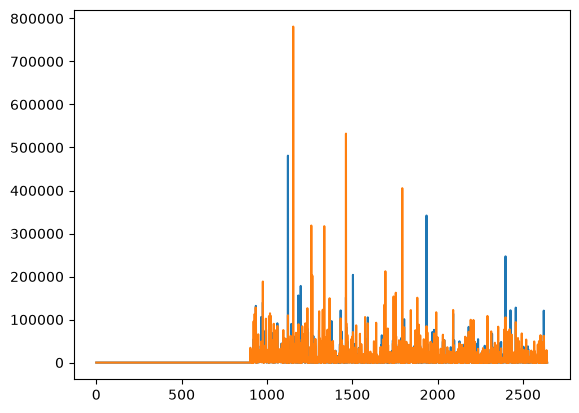

In [38]:
plt.plot(jnp.asarray(np.load('inv_mass_matrix_Gaia_XP_real_error_bars_synthetic_data.npy')))
plt.plot(jnp.diagonal(cov))
